# Colitis Ulcerative
## Sick vs Healthy prediction

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
# Loading the data
otu = pd.read_csv(
    "C:\\Users\\Morten\\Desktop\\metagenomic\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\otu_table.xls",
    sep="\t"
)

metadata = pd.read_csv(
    "C:\\Users\\Morten\\Desktop\\metagenomic\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\sample_data.xls",
    sep="\t"
)

In [3]:
# Preparing the data
otu = otu.set_index(otu.columns[0])

# Transposing
X = otu.T

In [4]:
# print column names of metadata
print(metadata.columns)

print(metadata['Disease.name'].value_counts())
print(metadata['Disease.MESH.ID'].value_counts())

#D006262 = raske
#D003093 = UC

Index(['#SampleID', 'Project.ID', 'Experiment.type', 'Nr..reads.sequenced',
       'Country', 'Sex', 'Host.age', 'BMI', 'Recent.antibiotics.use',
       'Disease.MESH.ID', 'Disease.name', 'QC.status'],
      dtype='str')
Disease.name
1    1066
Name: count, dtype: int64
Disease.MESH.ID
D006262    615
D003093    451
Name: count, dtype: int64


In [5]:
print(otu.columns)

Index(['ERR209057', 'ERR209058', 'ERR209059', 'ERR209060', 'ERR209061',
       'ERR209062', 'ERR209069', 'ERR209070', 'ERR209071', 'ERR209072',
       ...
       'SRR5983481', 'SRR5983484', 'SRR6876203', 'SRR6876204', 'SRR6876205',
       'SRR6876208', 'SRR6876210', 'SRR6876212', 'SRR6876223', 'SRR6876225'],
      dtype='str', length=1066)


In [6]:
metadata.head()

,#SampleID,Project.ID,Experiment.type,Nr..reads.sequenced,Country,Sex,Host.age,BMI,Recent.antibiotics.use,Disease.MESH.ID,Disease.name,QC.status
0,ERR209057,PRJEB1220,Metagenomics,7764468.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
1,ERR209058,PRJEB1220,Metagenomics,4465624.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
2,ERR209059,PRJEB1220,Metagenomics,9317812.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
3,ERR209060,PRJEB1220,Metagenomics,9644824.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
4,ERR209061,PRJEB1220,Metagenomics,9615221.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1


In [7]:
# count unique counts of Disease.MESH.ID in denmark, usa, spain (Country column)
print("Count of sick and healthy in Denmark:")
print(metadata[metadata['Country'] == 'Denmark']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in USA:")
print(metadata[metadata['Country'] == 'United States of America']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in Spain:")
print(metadata[metadata['Country'] == 'Spain']['Disease.MESH.ID'].value_counts())

Count of sick and healthy in Denmark:
Disease.MESH.ID
D006262    444
Name: count, dtype: int64
Count of sick and healthy in USA:
Disease.MESH.ID
D003093    138
D006262     55
Name: count, dtype: int64
Count of sick and healthy in Spain:
Disease.MESH.ID
D003093    223
D006262    116
Name: count, dtype: int64


In [8]:
metadata = metadata.dropna(subset=["Country"])

metadata = metadata[metadata["Country"] != "Denmark"]

print(metadata["Country"].value_counts())
print(metadata.shape)

Country
Spain                       339
United States of America    193
Name: count, dtype: int64
(532, 12)


In [9]:
# Preparing column names
metadata = metadata.reset_index(drop=True)

target_col = "Disease.MESH.ID"

metadata = metadata.set_index("#SampleID")

# Match metadata to OTU samples
common_samples = metadata.index.intersection(X.index)
metadata = metadata.loc[common_samples]
X = X.loc[common_samples]

y = metadata[target_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [13]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

param_dict = {
    'n_estimators' : [100, 150, 200, 250, 300],
    'max_depth' : [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split' : [2, 3, 4],
    'max_features' : ["sqrt", "log2", None]
    }

model = RandomForestClassifier(random_state=42)

gscv = GridSearchCV(model, param_dict, verbose=3, scoring='accuracy')

gscv.fit(X_train, y_train)

Fitting 5 folds for each of 495 candidates, totalling 2475 fits
[CV 1/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100;, score=0.812 total time=   0.1s
[CV 2/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100;, score=0.788 total time=   0.1s
[CV 3/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100;, score=0.800 total time=   0.1s
[CV 4/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100;, score=0.824 total time=   0.0s
[CV 5/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100;, score=0.788 total time=   0.1s
[CV 1/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=150;, score=0.824 total time=   0.2s
[CV 2/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=150;, score=0.824 total time=   0.2s
[CV 3/5] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=150;, score=0.812 tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 1, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [14]:
print(gscv.cv_results_)
print(gscv.best_params_, gscv.best_score_)
print(gscv.score(X_train, y_train)) 
print(gscv.score(X_test, y_test)) 

{'mean_fit_time': array([0.15774207, 0.25791063, 0.3500752 , 0.36375608, 0.45688071,
       0.14881182, 0.22135849, 0.29595752, 0.37173529, 0.42924194,
       0.14786177, 0.2244885 , 0.2897192 , 0.36094303, 0.43100853,
       0.14109817, 0.21501698, 0.28634791, 0.41297555, 0.49893069,
       0.16130862, 0.2467958 , 0.29805698, 0.36197982, 0.42850094,
       0.14503036, 0.21626368, 0.28526058, 0.35615106, 0.42584133,
       0.28277254, 0.41331682, 0.55329952, 0.67601957, 0.82338672,
       0.27640624, 0.43931146, 0.55379677, 0.69018626, 0.83050151,
       0.27954097, 0.40525522, 0.54269056, 0.71810007, 0.81728578,
       0.1241457 , 0.18655496, 0.25021234, 0.3043191 , 0.37738352,
       0.12343564, 0.18123164, 0.24367657, 0.30334501, 0.3695621 ,
       0.12462449, 0.19305973, 0.24519925, 0.31025324, 0.36851859,
       0.12983003, 0.18067012, 0.2392694 , 0.29864764, 0.36419115,
       0.12068205, 0.1800199 , 0.25330143, 0.29925947, 0.36624432,
       0.12651339, 0.19012241, 0.2417522 , 0

In [15]:
print(X_train.shape, y_train.shape)

(425, 78) (425,)


In [17]:
# Prediction
y_pred = gscv.predict(X_test)

In [18]:
# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        73
           1       0.81      0.65      0.72        34

    accuracy                           0.84       107
   macro avg       0.83      0.79      0.81       107
weighted avg       0.84      0.84      0.84       107



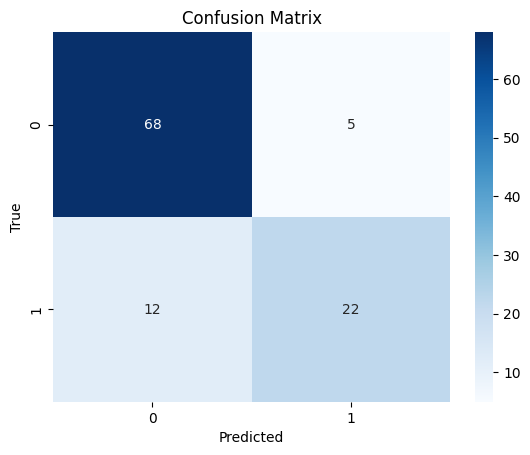

In [19]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

#categorical = ["Country", "Sex", "Recent.antibiotics.use"]

#numeric = ["Host.age", "BMI"]

# preprocessor = ColumnTransformer(
    #transformers=[
     #   ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
      #  ("num", StandardScaler(), numeric)
    #])


country = ["Country"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), country)
    ]
)

In [21]:
X_full = pd.concat(
    [X, metadata[country]],
    axis=1
)

X_full.columns = X_full.columns.astype(str)

In [22]:
X_full_encoded = pd.get_dummies(
    X_full,
    columns=["Country"], #"Sex", "Recent.antibiotics.use"
    dummy_na=True
)

In [24]:
X_full_encoded.columns = X_full_encoded.columns.astype(str)

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_full_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model_meta = RandomForestClassifier(
    n_estimators=300,
    max_features='log2',
    random_state=42
)

model_meta.fit(X_meta_train, y_meta_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Prediction
y_pred = model_meta.predict(X_meta_test)

In [26]:
# Evaluate
print(classification_report(y_meta_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89        73
           1       0.84      0.62      0.71        34

    accuracy                           0.84       107
   macro avg       0.84      0.78      0.80       107
weighted avg       0.84      0.84      0.83       107



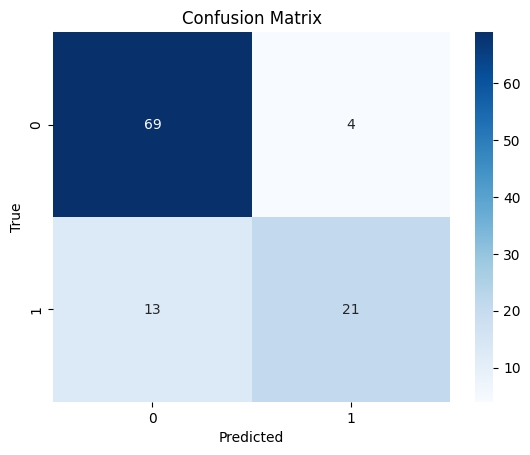

In [27]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_meta_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [59]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(100, 100), random_state=21, max_iter=2000)

model_mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",21


              precision    recall  f1-score   support

           0       0.86      0.95      0.90        73
           1       0.85      0.68      0.75        34

    accuracy                           0.86       107
   macro avg       0.86      0.81      0.83       107
weighted avg       0.86      0.86      0.85       107



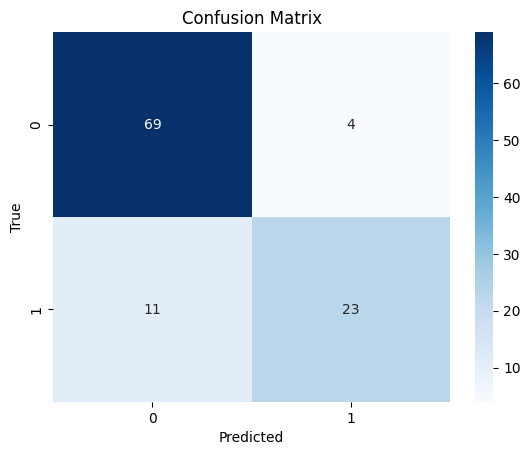

In [60]:
y_mlp = model_mlp.predict(X_test)

print(classification_report(y_test, y_mlp))

cm = confusion_matrix(y_test, y_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [72]:
model_mlp = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(100, 100), random_state=21, max_iter=2000)

model_mlp.fit(X_meta_train, y_meta_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",21


              precision    recall  f1-score   support

           0       0.90      0.88      0.89        73
           1       0.75      0.79      0.77        34

    accuracy                           0.85       107
   macro avg       0.83      0.84      0.83       107
weighted avg       0.85      0.85      0.85       107



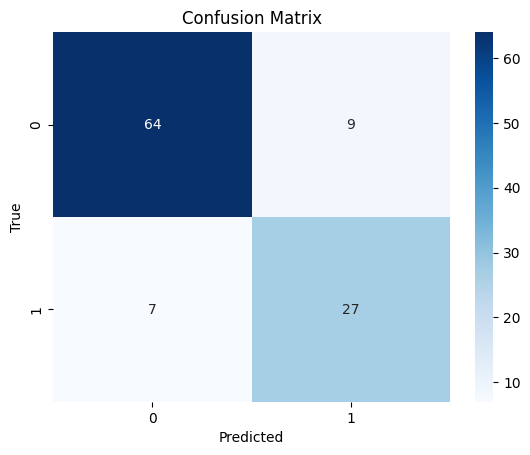

In [73]:
y_mlp = model_mlp.predict(X_meta_test)

print(classification_report(y_meta_test, y_mlp))

cm = confusion_matrix(y_meta_test, y_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()